### Clustering with K-Means

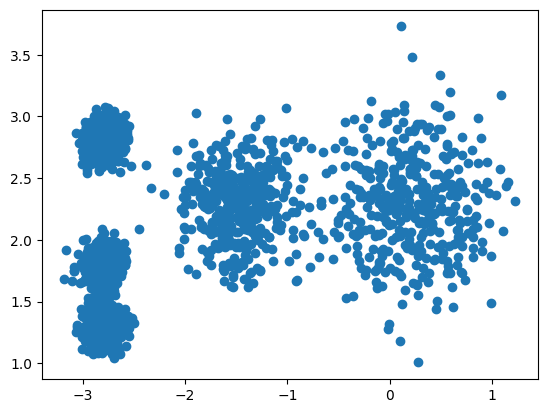

In [5]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

blob_centers = np.array([
    [ 0.2,  2.3], 
	[-1.5 ,  2.3], 
	[-2.8,  1.8],
	[-2.8,  2.8], 
	[-2.8,  1.3]
])

blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

X, y = make_blobs(
    n_samples=2000,
    centers=blob_centers,
    cluster_std=blob_std,
    random_state=123
)

plt.scatter(X[:, 0], X[:, 1])
plt.show()

c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


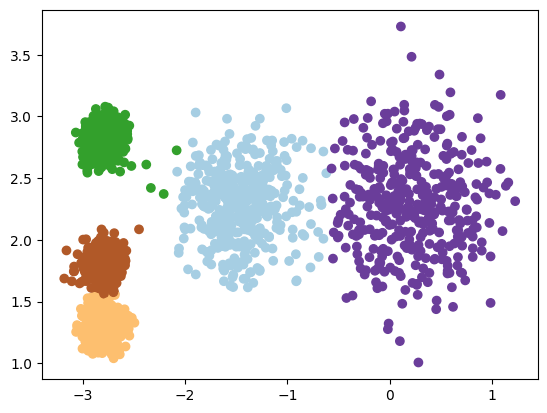

In [14]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=1)
y_pred = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='Paired')
plt.show()

In [15]:
centroids = kmeans.cluster_centers_
centroids

array([[-1.45400251,  2.28240421],
       [-2.7979204 ,  2.80239567],
       [-2.79959856,  1.30967879],
       [ 0.22211271,  2.29488501],
       [-2.80240931,  1.80817477]])

In [16]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
distances = kmeans.transform(X_new) 
distances

array([[1.48117367, 2.91070393, 2.88345201, 0.36917641, 2.80896687],
       [4.4629464 , 5.85318031, 5.84053823, 2.79349512, 5.80557927],
       [1.70442129, 0.28263694, 1.70215937, 3.29836284, 1.20809332],
       [1.56123546, 0.36370222, 1.20707303, 3.22863477, 0.71948887]])

##### The Radial Basis Function (RBF) Kernel, also known as the Gaussian Kernel:

In [17]:
from sklearn.metrics.pairwise import rbf_kernel

rbf_kernel(X_new, kmeans.cluster_centers_, gamma=0.5).round(3)

array([[0.334, 0.014, 0.016, 0.934, 0.019],
       [0.   , 0.   , 0.   , 0.02 , 0.   ],
       [0.234, 0.961, 0.235, 0.004, 0.482],
       [0.296, 0.936, 0.483, 0.005, 0.772]])

### Inertia and K-Means score

In [18]:
kmeans.inertia_

210.31915471169458

In [20]:
kmeans.score(X)

-210.3191547116946

In [21]:
np.sum(np.linalg.norm(X - centroids[y_pred], axis=1) ** 2)

np.float64(210.31915471169458)

### Multiple initializations and K-Means++

K-Means++ improves initialization by spreading centers apart, and multiple initializations ensure the algorithm finds the best clustering among several runs.

In [22]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++', #default
    n_init=10,
    random_state=123
)

kmeans.fit(X)

c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,123
,copy_x,True
,algorithm,'lloyd'


### Mini-Batch K-Means

In [29]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=1)
minibatch_kmeans.fit(X)

minibatch_kmeans.inertia_

c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


210.34972670765086

c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


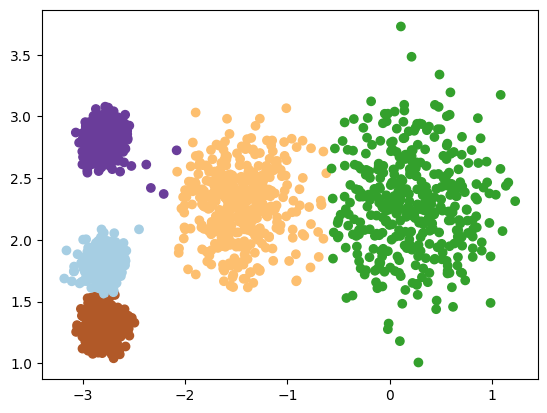

In [30]:
y_pred = minibatch_kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='Paired')
plt.show()

### Choosing k: Elbow and Silhouette

In [31]:
inerties = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(X)
    inerties.append(kmeans.inertia_)

c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

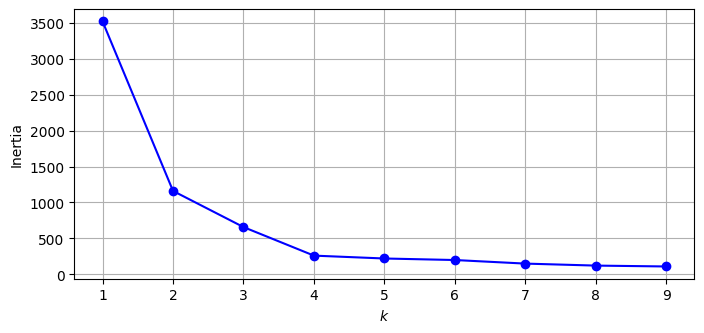

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inerties, 'bo-')
plt.xlabel('$k$')
plt.ylabel('Inertia')
plt.grid()

In [36]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=4, random_state=123)
kmeans.fit(X)
score = silhouette_score(X, kmeans.labels_)
score

c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


0.6896117031197512

### Gaussion Mixture Models (GMM)